In [ ]:
# World Happiness Report Dataset



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#1 DATA LOAD

df = pd.read_csv("wh.csv")
df

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298
...,...,...,...,...,...,...,...,...,...
151,152,Rwanda,3.334,0.359,0.711,0.614,0.555,0.217,0.411
152,153,Tanzania,3.231,0.476,0.885,0.499,0.417,0.276,0.147
153,154,Afghanistan,3.203,0.350,0.517,0.361,0.000,0.158,0.025
154,155,Central African Republic,3.083,0.026,0.000,0.105,0.225,0.235,0.035


In [4]:
#2 BASIC INFO:

print(df.shape)
df.info()
print(df.describe())
print(df.isnull().sum())

(156, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 11.1+ KB
       Overall rank       Score  GDP per capita  Social support  \
count    156.000000  156.000000      156.000000      156.000000   
mean      78.500000    5.407096        0.

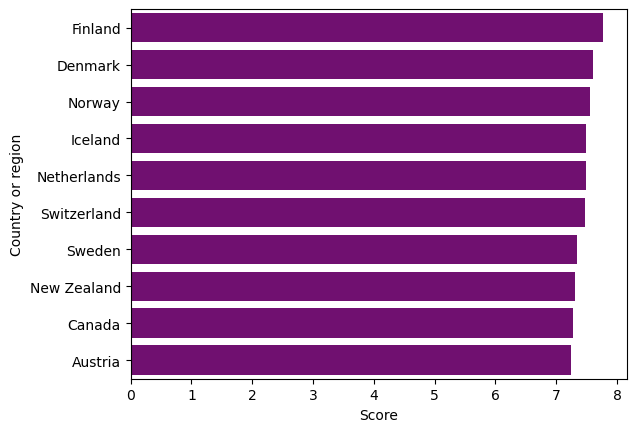

In [6]:
# 3 TOP 10 HIGHEST COUNTRIES

top10 = df.nlargest(10,"Score")
sns.barplot(data=top10,x="Score",y="Country or region",color="purple")
plt.show()

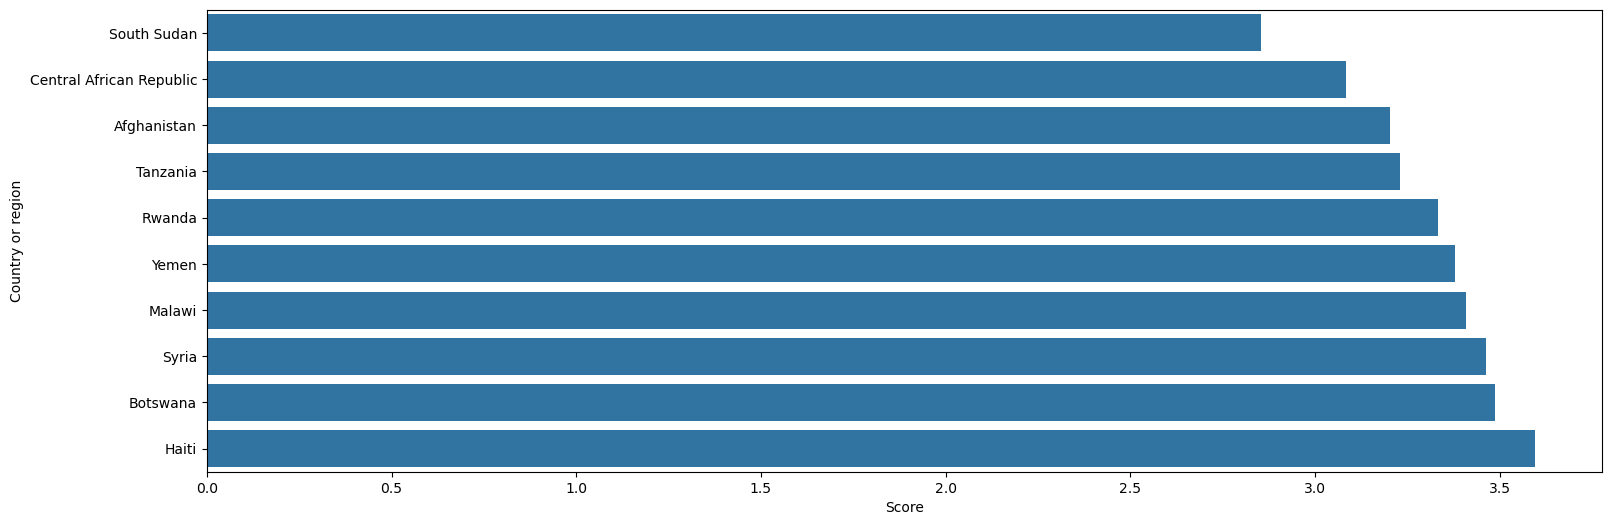

In [29]:
# 4 TOP 10 LEAST HAPPY COUNTRIES:

lest10 = df.nsmallest(10,"Score")
plt.figure(figsize=(18,6))
sns.barplot(data=lest10,x="Score",y="Country or region")
plt.show()

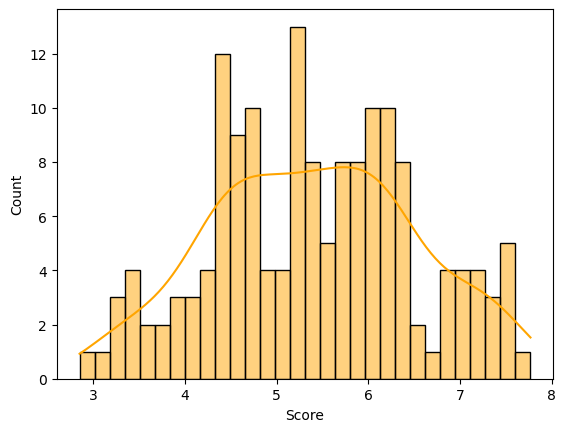

In [34]:
# 5 Happiness Score Distribution:

sns.histplot(df["Score"],bins=30,kde=True,color="orange")
plt.show()

In [8]:
dd = df.rename(columns={"GDP per capita":"GDP",
                "Country or region":"country",
                "Healthy life expectancy":"life exp"})
dd


,Overall rank,country,Score,GDP,Social support,life exp,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298
...,...,...,...,...,...,...,...,...,...
151,152,Rwanda,3.334,0.359,0.711,0.614,0.555,0.217,0.411
152,153,Tanzania,3.231,0.476,0.885,0.499,0.417,0.276,0.147
153,154,Afghanistan,3.203,0.350,0.517,0.361,0.000,0.158,0.025
154,155,Central African Republic,3.083,0.026,0.000,0.105,0.225,0.235,0.035


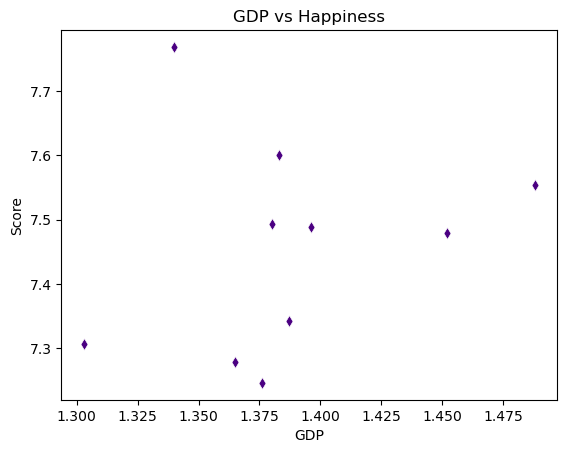

In [23]:
# 6 GDP vs Happiness:

t = dd.head(10)
sns.scatterplot(data=t,x="GDP",y="Score",color="indigo",marker="d")
plt.title("GDP vs Happiness")
plt.show()

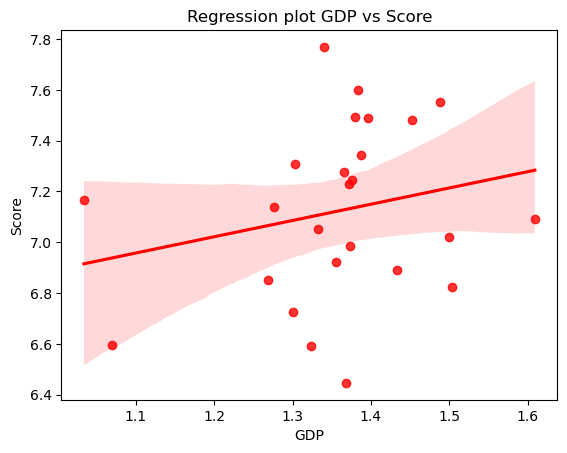

In [78]:
# 7 Regression Plot:

sns.regplot(data=t,x="GDP",y="Score",color="red")
plt.title("Regression plot GDP vs Score")
plt.show()

<Axes: xlabel='Social support', ylabel='Score'>

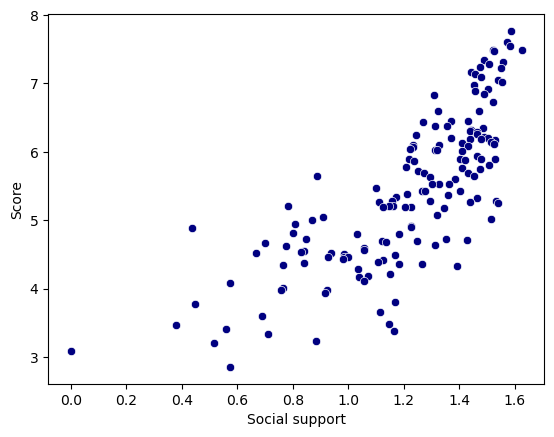

In [20]:
#8. Social Support vs Happiness
sns.scatterplot(data=dd,x="Social support",y="Score",color="navy")

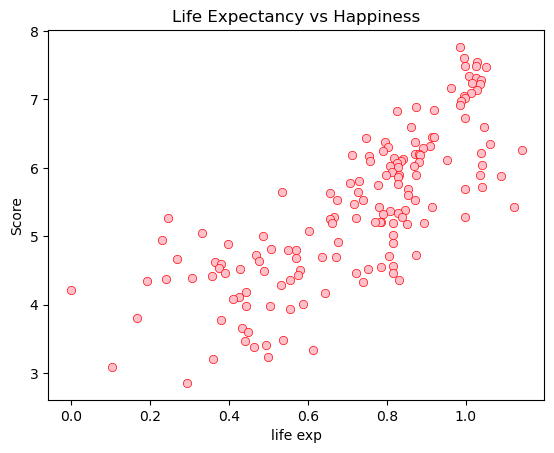

In [14]:
#10. Life Expectancy vs Happiness

sns.scatterplot(data=dd,x="life exp",y="Score",color="pink",edgecolor="red")
plt.title("Life Expectancy vs Happiness")
plt.show()

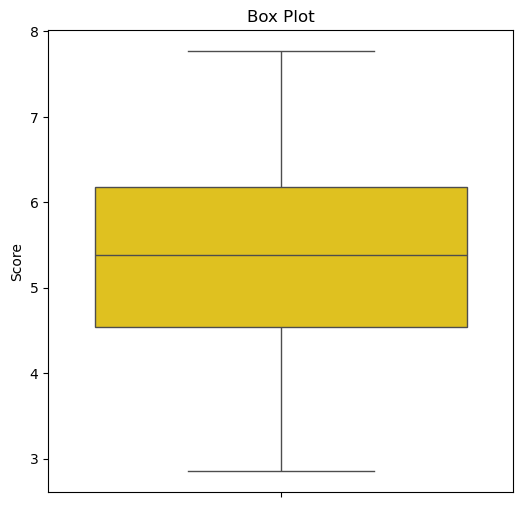

In [19]:
#11. box plot
plt.figure(figsize=(6,6))
sns.boxplot(y=dd["Score"],color="gold")
plt.title("Box Plot")
plt.show()

In [17]:
dd.columns.tolist()

['Overall rank',
 'country',
 'Score',
 'GDP',
 'Social support',
 'life exp',
 'Freedom to make life choices',
 'Generosity',
 'Perceptions of corruption']

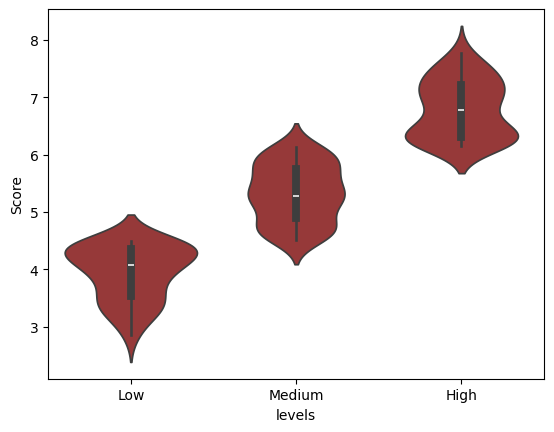

In [33]:
#12 Violin Plot

dd["levels"]=pd.cut(dd["Score"],bins=3,labels=["Low","Medium","High"])
sns.violinplot(x="levels",y="Score",data=dd,color="brown")
plt.show()

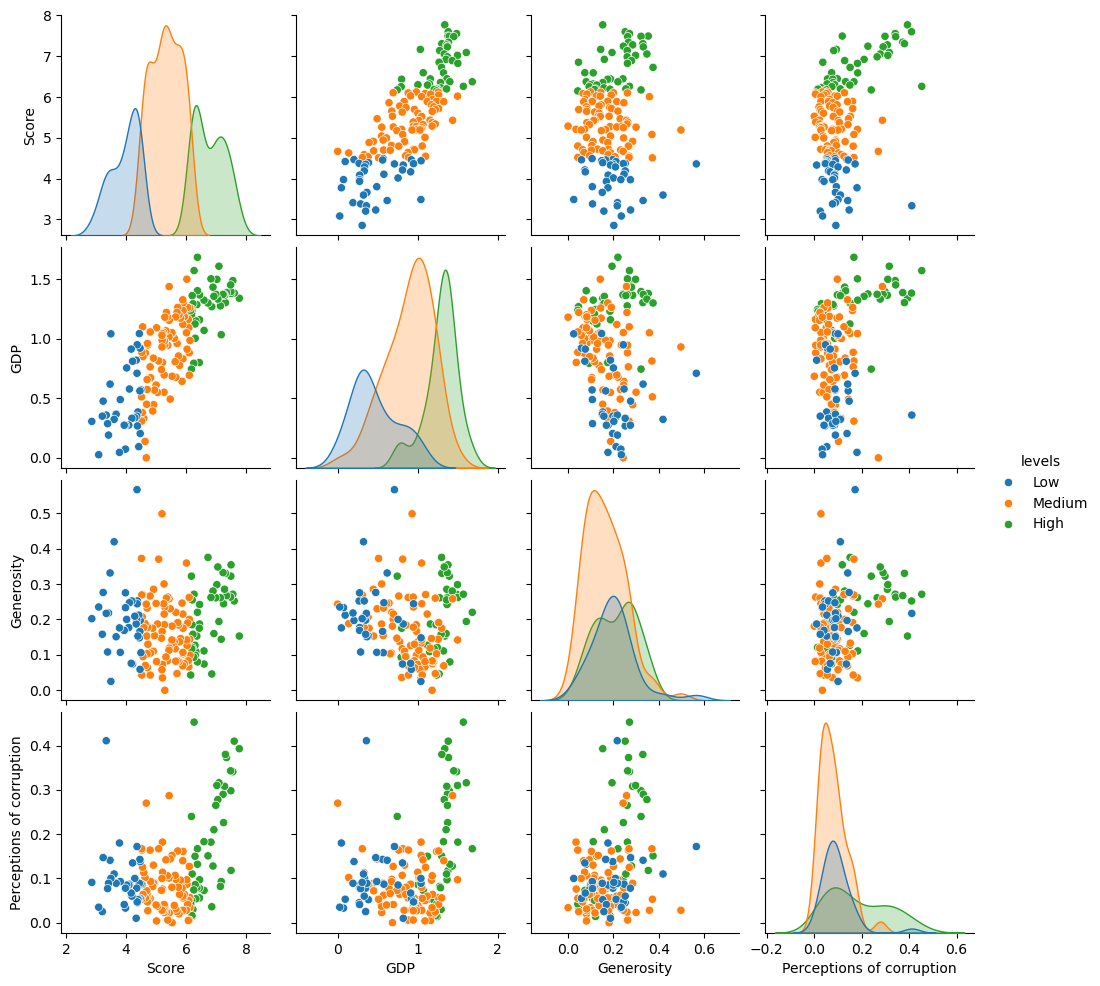

In [41]:
# 13.Pair Plot

sns.pairplot(dd,vars=["Score","GDP","Generosity","Perceptions of corruption"],hue="levels")
plt.show()

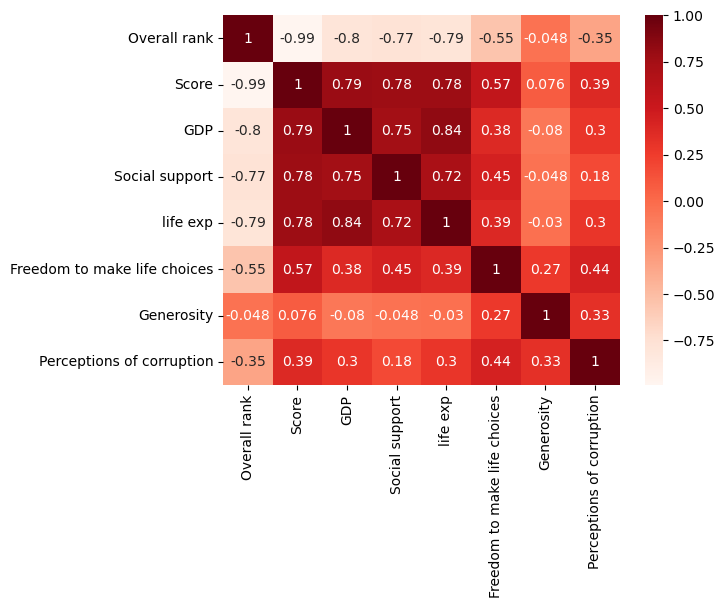

In [48]:
#14. Heatmap

heat = dd.select_dtypes(include=np.number)

sns.heatmap(heat.corr(),annot=True,cmap="Reds")
plt.show()

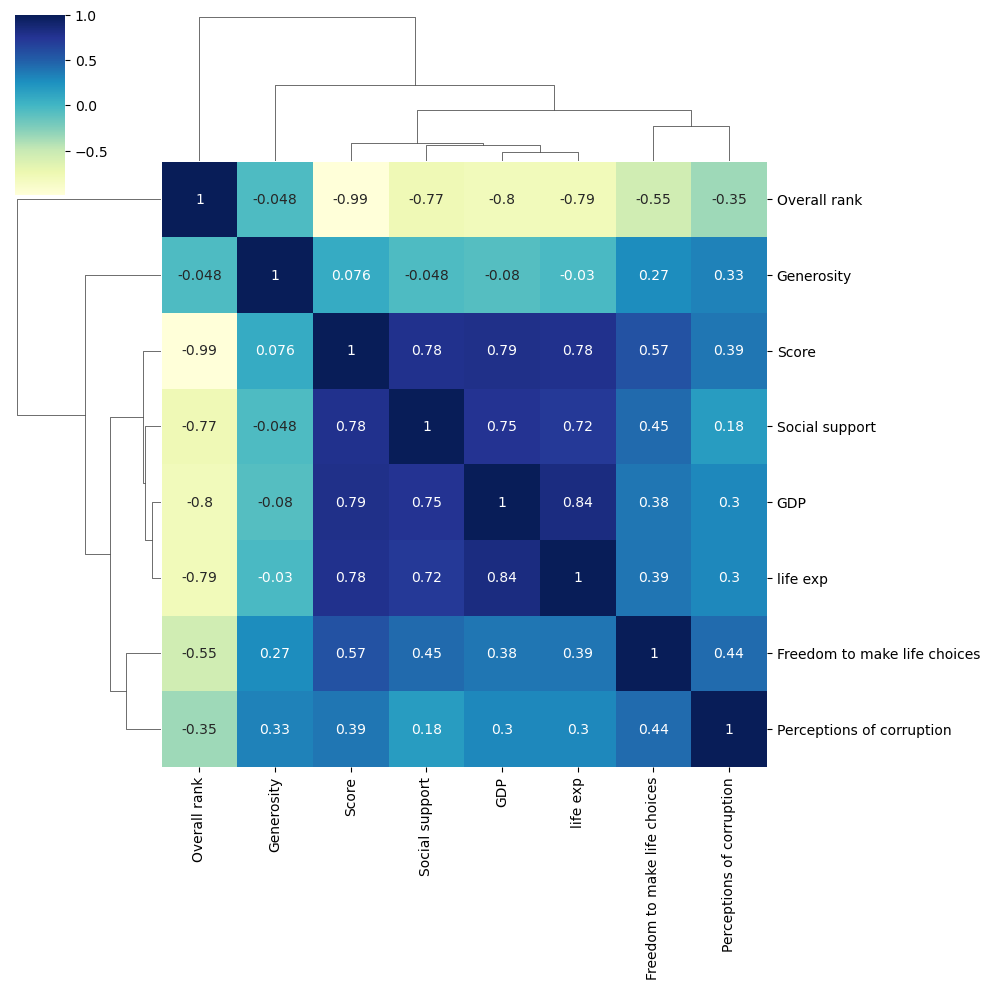

In [54]:
#15 Cluster map

sns.clustermap(heat.corr(),annot=True,cmap="YlGnBu")

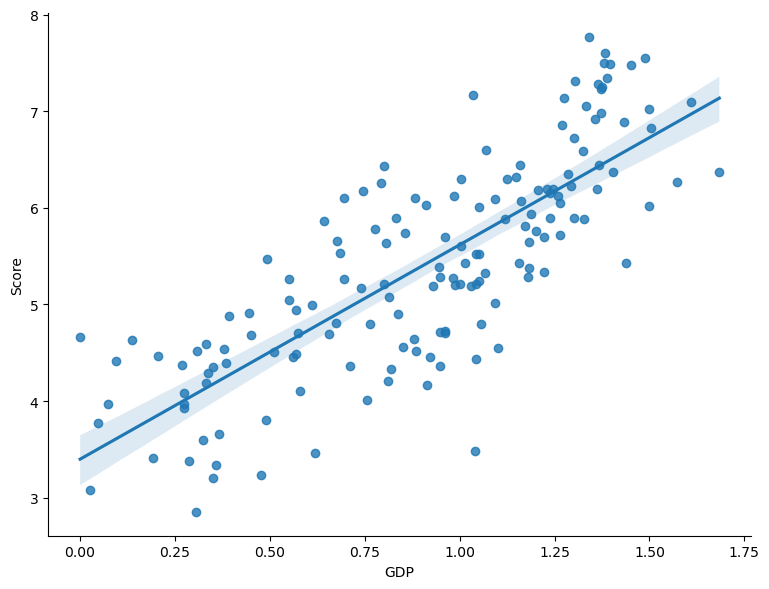

In [60]:
# 17 Lm plot
sns.lmplot(data=dd,x="GDP",y="Score",height=6,aspect=1.3)

plt.show()

In [61]:
# 18 Clean 

dd.to_csv("World_Happiness.csv",index=False)